In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv(r"D:\DSML\netflix-statistical-analysis\data\netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Preparation
Convert movie duration to numeric

In [3]:
df_movies = df[df['type'] == 'Movie'].copy()

# Replace ' min' with empty string
df_movies['duration'] = df_movies['duration'].str.replace(' min','')

# Handle 'Unknown' values before converting to float
# Option 1: Replace 'Unknown' with NaN
df_movies['duration'] = df_movies['duration'].replace('Unknown', float('nan'))
df_movies['duration'] = df_movies['duration'].astype(float)

# Alternative Option 2: Use pd.to_numeric with errors='coerce' to automatically convert invalid values to NaN
# df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

## Descriptive Statistics

In [4]:
df_movies['duration'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

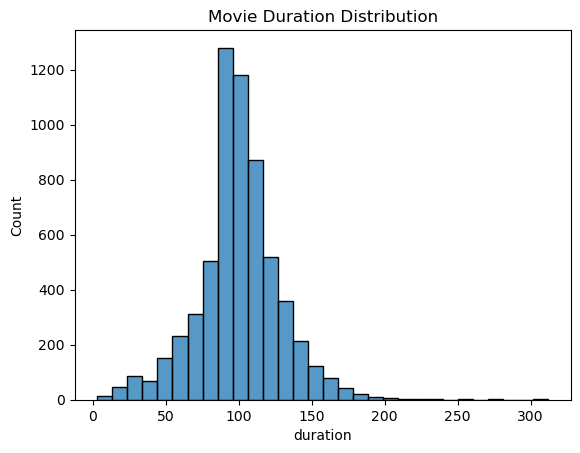

In [5]:
sns.histplot(df_movies['duration'], bins=30)
plt.title("Movie Duration Distribution")
plt.savefig(r'D:\DSML\netflix-statistical-analysis\images\movie_duration_distribution.png',dpi=300, bbox_inches='tight')

plt.show()

## Hypothesis Testing
Research Question:
Do Netflix movies differ significantly from 100 minutes average?

## Hypothesis
H0: mean duration = 100 minutes
H1: mean duration ≠ 100 minutes

In [6]:
# Test
duration = df_movies['duration'].dropna()

stats.ttest_1samp(duration, 100)

TtestResult(statistic=np.float64(-1.169946431211949), pvalue=np.float64(0.24206803394773344), df=np.int64(6127))

p-value = 0.242  

Since the p-value (0.242) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant evidence that Netflix movie durations differ from 100 minutes on average.

## Correlation Analysis

Check correlation between release year and movie duration.

In [7]:
df_movies[['release_year','duration']].corr()

,release_year,duration
release_year,1.000000,-0.206285
duration,-0.206285,1.000000


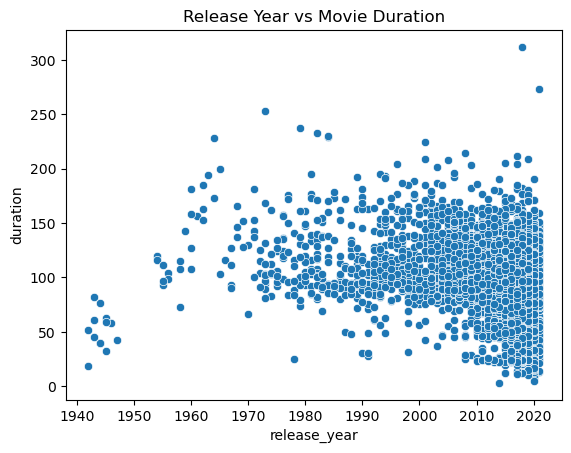

In [8]:
sns.scatterplot(x='release_year', y='duration', data=df_movies)
plt.title("Release Year vs Movie Duration")
plt.savefig(r'D:\DSML\netflix-statistical-analysis\images\duration_vs_year.png',dpi=300, bbox_inches='tight')
plt.show()

## Confidence Interval
Calculate 95% confidence interval.

In [9]:
mean = df_movies['duration'].mean()
std = df_movies['duration'].std()
n = len(df_movies)

stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

(np.float64(98.86889808706493), np.float64(100.28547528108129))

## Interpretation

We are 95% confident that the true average duration of Netflix movies lies between:

 98.87 minutes and 100.29 minutes

## Regression Analysis

Regression model:

In [18]:
model = smf.ols('duration ~ release_year', data=df_movies).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     272.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.02e-60
Time:                        01:28:32   Log-Likelihood:                -29045.
No. Observations:                6128   AIC:                         5.809e+04
Df Residuals:                    6126   BIC:                         5.811e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1313.2183     73.552     17.854   

## Key Statistical Findings

1. The average duration of Netflix movies is 99.58 minutes, which is very close to the typical industry standard of 100 minutes.

2. Most movies fall between 87 and 114 minutes, indicating that Netflix films generally follow a standard feature-length format.

3. A one-sample t-test shows no statistically significant difference between the average Netflix movie duration and 100 minutes (p = 0.242).

4. The correlation between release year and movie duration is -0.206, suggesting a weak negative relationship, meaning newer movies tend to be slightly shorter.

5. The 95% confidence interval for the true mean duration is 98.87–100.29 minutes, confirming that the average movie duration is around 100 minutes.

6. Regression analysis indicates that movie duration decreases by approximately 0.6 minutes per year, though the relationship is weak (R² = 0.043).
